<h1> Regularizers </h1>

This Notebook is used to find a regularizer that rewards heavy tailes during training 

In [15]:
from scipy.stats import levy_stable
import numpy as np
import polars as pl
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd
import torch
import plotly.express as px

In [12]:
gaussian_data = levy_stable.rvs(2,0.0, size=1000)
ht_1_5_data = levy_stable.rvs(1.5, 0.5, size=1000)
ht_1_data = levy_stable.rvs(1, 0.0, size=1000)

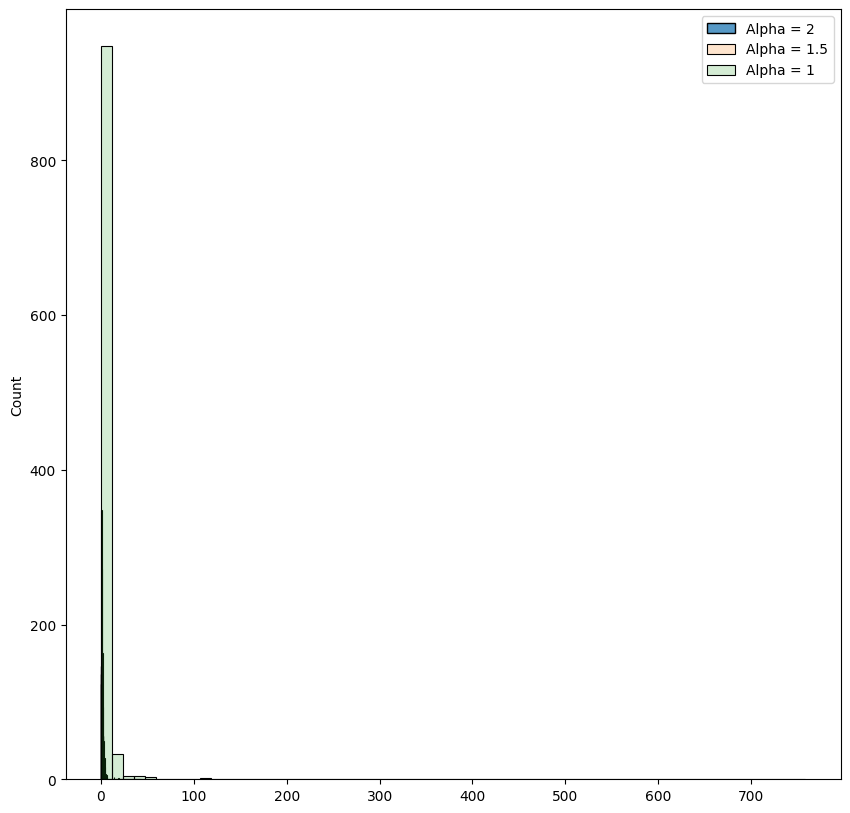

In [13]:
fig, ax = plt.subplots(figsize=(10,10))

sns.histplot(np.abs(gaussian_data), label="Alpha = 2", ax=ax)
sns.histplot(np.abs(ht_1_5_data), label="Alpha = 1.5", ax=ax, alpha=0.2)
sns.histplot(np.abs(ht_1_data), label="Alpha = 1", ax=ax, alpha=0.2)

ax.legend()

In [16]:

df = pd.DataFrame({
    "abs_values": np.concatenate([np.abs(gaussian_data),
                                  np.abs(ht_1_5_data),
                                  np.abs(ht_1_data)]),
    "alpha": (["2"]*len(gaussian_data) + 
              ["1.5"]*len(ht_1_5_data) + 
              ["1"]*len(ht_1_data))
})

# Histogramm in Plotly Express
fig = px.histogram(df, x="abs_values", color="alpha", barmode="overlay",
                   nbins=1000, opacity=0.6,
                   labels={"alpha": "Tail exponent α"},
                   title="Comparison of Absolute Values for Different α")

fig.show()

<Axes: >

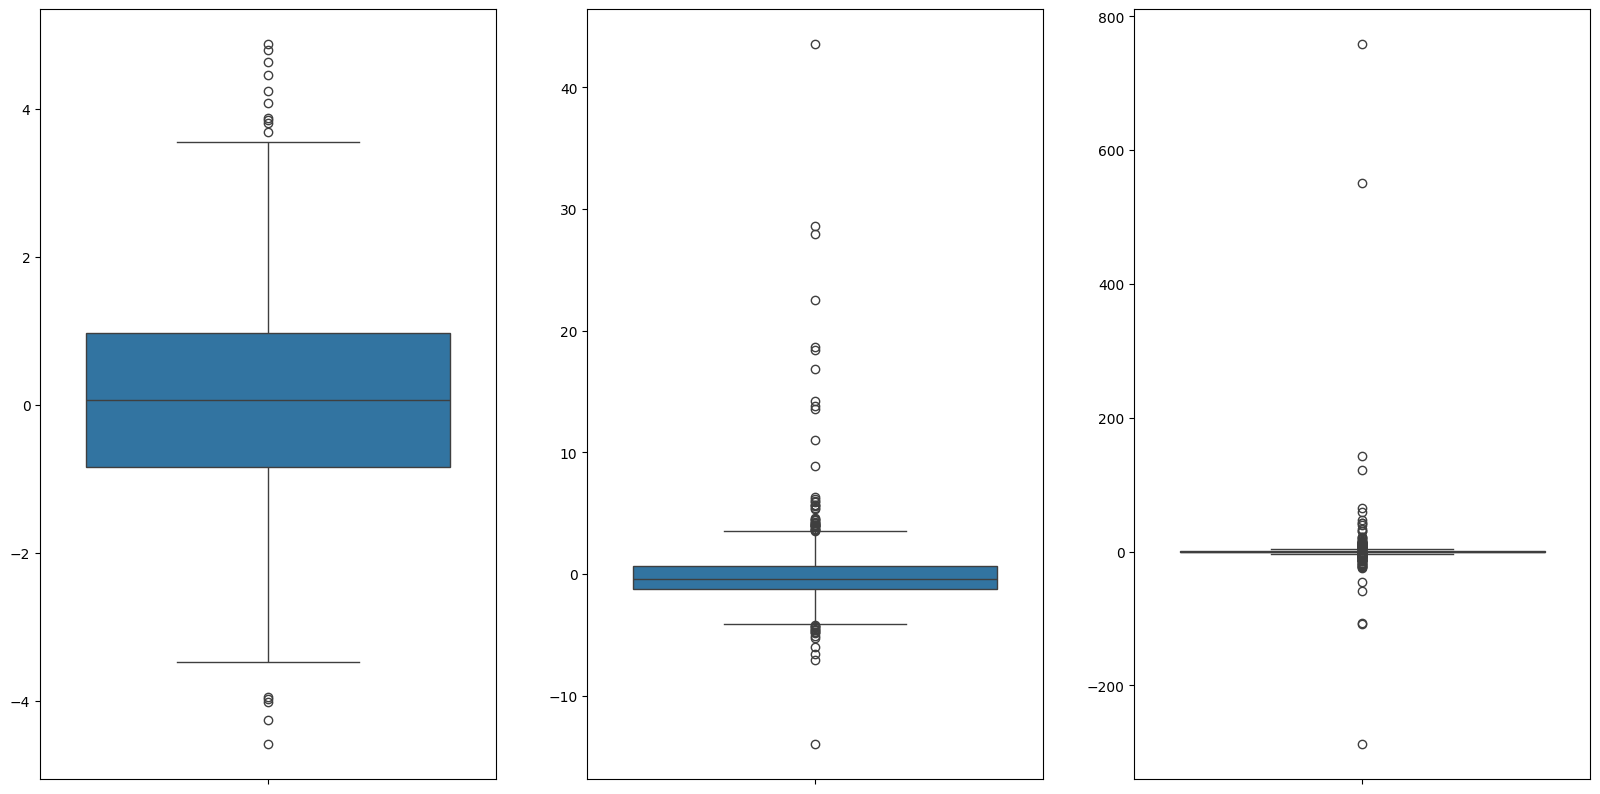

In [17]:
fig, axes = plt.subplots(figsize=(20,10), ncols=3)

sns.boxplot(gaussian_data, ax=axes[0])
sns.boxplot(ht_1_5_data, ax=axes[1])
sns.boxplot(ht_1_data, ax=axes[2])

In [18]:
def count_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = (data < lower) | (data > upper)
    return np.sum(outliers)

count_outliers_iqr(gaussian_data), count_outliers_iqr(ht_1_5_data), count_outliers_iqr(ht_1_data)

df_alpha_outliers = pd.DataFrame()

for i in np.linspace(0.1,2, 100): 
    data = levy_stable.rvs(i, 0.5, size=1000)
    n_outliers = count_outliers_iqr(data)
    df = pd.DataFrame({
            "alpha": [i], 
            "n_outliers": [n_outliers]})
    df_alpha_outliers = pd.concat([df_alpha_outliers, df])

<Axes: xlabel='alpha', ylabel='n_outliers'>

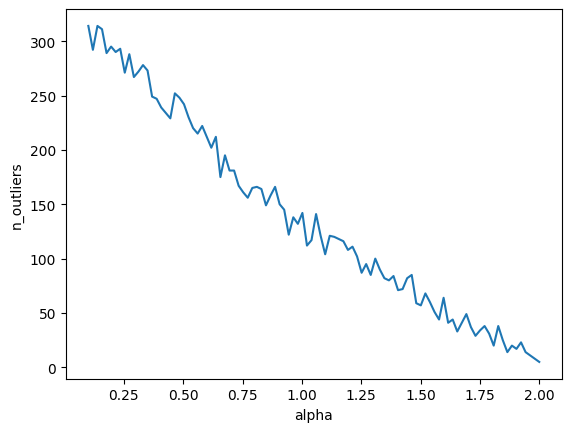

In [19]:
sns.lineplot(data=df_alpha_outliers, x="alpha", y="n_outliers")

In [188]:

def soft_outlier_indicator(x, lower, upper, sharpness=10.0):
    """
    Differenzierbarer weicher Ausreißer-Indikator
    - x: Tensor
    - lower, upper: Grenzen (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    - sharpness: wie steil die Kurve ist (größer = näher an hart)
    
    Ausgabe: 0 im Intervall [lower, upper], 1 außerhalb
    """
    # Sigmoid unten: geht gegen 1, wenn x << lower
    lower_score = torch.sigmoid(-sharpness * (x - lower))
    
    # Sigmoid oben: geht gegen 1, wenn x >> upper
    upper_score = torch.sigmoid(sharpness * (x - upper))
    
    # Combine: Summe capped auf 1 (optional)
    indicator = torch.clamp(lower_score + upper_score, 0.0, 1.0)
    return indicator


def soft_outlier_regularizer(weights, factor=1.5):
    w = weights.flatten()
    Q1 = torch.quantile(w, 0.25)
    Q3 = torch.quantile(w, 0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    
    outliers = soft_outlier_indicator(weights, lower, upper)
    
    loss = -torch.sum(outliers)
    return loss


In [24]:
soft_outlier_regularizer(torch.tensor(gaussian_data)), soft_outlier_regularizer(torch.tensor(ht_1_5_data)), soft_outlier_regularizer(torch.tensor(ht_1_data))

(tensor(-15.4759, dtype=torch.float64),
 tensor(-57.6295, dtype=torch.float64),
 tensor(-146.5612, dtype=torch.float64))

In [25]:
weights = torch.tensor(gaussian_data)

w = weights.flatten()
Q1 = torch.quantile(w, 0.25)
Q3 = torch.quantile(w, 0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


lower, upper

(tensor(-3.5586, dtype=torch.float64), tensor(3.6767, dtype=torch.float64))

<Axes: >

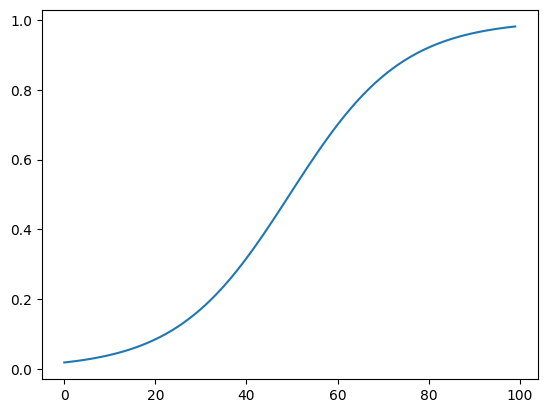

In [26]:
outlier_scores = torch.sigmoid(w - upper) + torch.sigmoid(lower - w)

sns.lineplot(torch.sigmoid(torch.tensor(np.linspace(-4,4,100))))

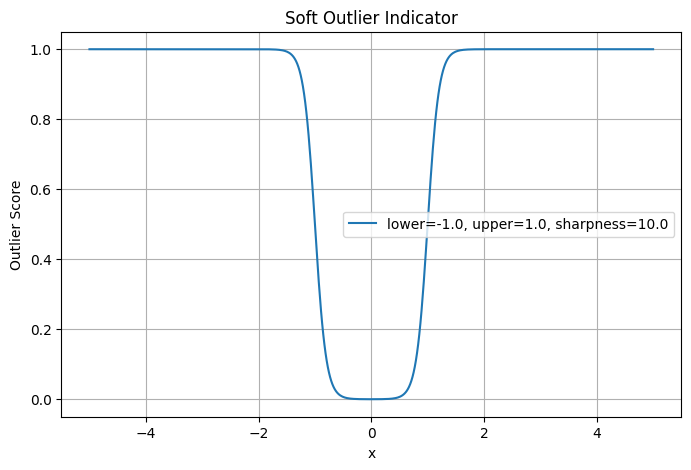

In [ ]:

x = torch.linspace(-5, 5, 500)  


lower, upper = -1.0, 1.0
sharpness = 10.0


y = soft_outlier_indicator(x, lower, upper, sharpness=sharpness)


plt.figure(figsize=(8,5))
plt.plot(x.numpy(), y.detach().numpy(), label=f"lower={lower}, upper={upper}, sharpness={sharpness}")
plt.xlabel("x")
plt.ylabel("Outlier Score")
plt.title("Soft Outlier Indicator")
plt.grid(True)
plt.legend()
plt.show()


Does not consider the magnitude of outlier!

In [177]:
data_gauss = levy_stable.rvs(2,0.5, size=1000)
data_ht= levy_stable.rvs(1.5,0.5, size=1000)
data_ht2= levy_stable.rvs(1.0,0.5, size=1000)

result = -(1/len(data))*(data-10)*(data-15)

In [262]:
def soft_magnitude_outlier_regularizer(weights, 
                                       multiplier=1.0, beta=0.2, p=1.0,
                                       reduction="mean"):
    x = weights.view(-1)
    Q1 = torch.quantile(w, 0.25)
    Q3 = torch.quantile(w, 0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    s = -(x - lower) * (x - upper)               
    bounded = multiplier * torch.tanh(-beta * s)  
    mag = (1.0 + x.abs()**p)                   
    per_weight = bounded * mag
    return per_weight.mean() if reduction=='mean' else per_weight.sum()
    return s.sum()

#2. SOMAR — Soft Magnitude Outlier Regularizer -> name von chatti
# SoMoRe


def outlier_reward(weights, p=0.5, reduction="mean"):
    x = weights.view(-1)
    Q1 = torch.quantile(x, 0.25)
    Q3 = torch.quantile(x, 0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    reward = torch.log1p(torch.relu(x - upper)) * (x.abs()**p)

    if reduction == "mean":
        return reward.mean()
    else:
        return reward.sum()


def remore(weights, p=0.5, multiplier=10.0, reduction="mean"):
    x = weights.view(-1)


    Q1 = torch.quantile(x, 0.25)
    Q3 = torch.quantile(x, 0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR

    reward = torch.relu(x.abs() - upper)**p
    reward = reward * multiplier

    if reduction == "mean":
        return -reward.mean()
    else:
        return -reward.sum()




In [ ]:
def smor(weights, alpha=0.001, reduction="mean"):
    x = weights.view(-1)


    Q1 = torch.quantile(x, 0.25)
    Q3 = torch.quantile(x, 0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    raw = (x - lower) * (x - upper)
    raw = raw / (1 + alpha * raw.abs())


    if reduction == "mean":
        return -raw.mean()
    else:
        return -raw.sum()

In [267]:
def parom(weights, reduction="mean"):
    #parabolic reward outlier mechanism
    x = weights.view(-1)


    Q1 = torch.quantile(x, 0.25)
    Q3 = torch.quantile(x, 0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR

    raw = (1/x.abs().max()) * (x - lower) * (x - upper)
    
    if reduction == "mean":
        return -raw.mean()
    else:
        return -raw.sum()

In [259]:
outlier_reward(torch.tensor(data_gauss)), outlier_reward(torch.tensor(data_ht)), outlier_reward(torch.tensor(data_ht2))

(tensor(0.0039, dtype=torch.float64),
 tensor(0.1981, dtype=torch.float64),
 tensor(2.4204, dtype=torch.float64))

In [260]:
soft_magnitude_outlier_regularizer(torch.tensor(data_gauss)), soft_magnitude_outlier_regularizer(torch.tensor(data_ht)), soft_magnitude_outlier_regularizer(torch.tensor(data_ht2))

(tensor(-1.9048, dtype=torch.float64),
 tensor(-1.1768, dtype=torch.float64),
 tensor(19.7128, dtype=torch.float64))

In [269]:
remore(torch.tensor(data_gauss)), remore(torch.tensor(data_ht)), remore(torch.tensor(data_ht2))

(tensor(-0.0451, dtype=torch.float64),
 tensor(-1.1606, dtype=torch.float64),
 tensor(-5.2569, dtype=torch.float64))

In [270]:
smor(torch.tensor(data_gauss)), smor(torch.tensor(data_ht)), smor(torch.tensor(data_ht2))

(tensor(11.6254, dtype=torch.float64),
 tensor(7.8171, dtype=torch.float64),
 tensor(-8.8192, dtype=torch.float64))

In [271]:
parom(torch.tensor(data_gauss)), parom(torch.tensor(data_ht)), parom(torch.tensor(data_ht2))

(tensor(2.3008, dtype=torch.float64),
 tensor(-0.0445, dtype=torch.float64),
 tensor(-17.0392, dtype=torch.float64))

In [204]:
np.abs(data_gauss).mean()

np.float64(1.1144932873179854)

In [244]:
x = np.linspace(5,20,10000)
alpha = 0.001
multiplier = 10
lower, upper = 10,15

raw = (x - lower) * (x - upper)
raw = raw / (1 + alpha * np.abs(raw))

<Axes: >

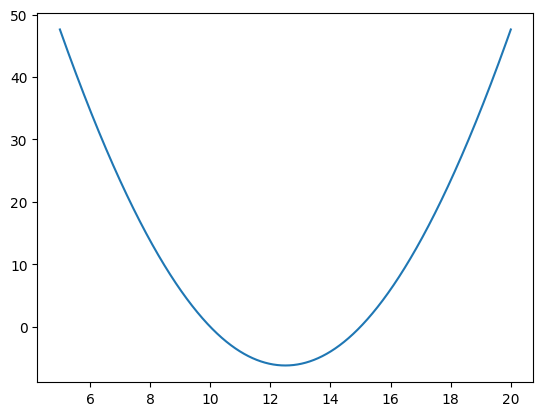

In [245]:
sns.lineplot(x=x, y=raw)